# DRG Classification — Final Reproducible Notebook

This notebook contains the final, report-oriented pipeline for predicting Diagnosis Related Groups (DRG/GRD) from structured patient data. It keeps only the components required to support the report: data loading, preprocessing, EDA, target filtering, feature-combination search, final neural-network experiments, Random Forest baseline experiments, and final report outputs.

Primary metric: **macro-F1**, because the task is multiclass and strongly imbalanced.

## 1. Imports and configuration

In [4]:

import os
import re
import gc
import json
import time
import random
import itertools
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    top_k_accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

BASE_PATH = Path.cwd()
DATA_PATH = BASE_PATH / "data" / "raw" / "dataset_elpino.csv"
OUTPUT_DIR = BASE_PATH / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

TARGET_THRESHOLD = 30
TEST_SIZE = 0.20
VALIDATION_SPLIT = 0.20
BATCH_SIZE = 64

print("Base path:", BASE_PATH)
print("Expected dataset path:", DATA_PATH)

Base path: c:\Desarrollo\Proyectos\Activos\clinical-grd-classification\notebooks\FINAL
Expected dataset path: c:\Desarrollo\Proyectos\Activos\clinical-grd-classification\notebooks\FINAL\data\raw\dataset_elpino.csv


## 2. Dataset loading

The dataset is expected at `data/raw/dataset_elpino.csv` using semicolon separation. If the file is stored elsewhere, update `DATA_PATH` in the configuration cell.

In [5]:

if not DATA_PATH.exists():
    # try to find a matching CSV under the notebook tree (flexible fallback)
    candidates = list(BASE_PATH.rglob("dataset_elpino*.csv"))
    if candidates:
        DATA_PATH = candidates[0]
        print(f"Using dataset found at: {DATA_PATH}")
    else:
        # try a couple of plausible parent locations
        fallback = None
        for p in (BASE_PATH, BASE_PATH.parent, BASE_PATH.parent.parent):
            if p is None:
                continue
            cand = p / "data" / "raw" / "dataset_elpino.csv"
            if cand.exists():
                fallback = cand
                break
        if fallback:
            DATA_PATH = fallback
            print(f"Using dataset found at: {DATA_PATH}")
        else:
            raise FileNotFoundError(
                f"Dataset not found at {DATA_PATH}. Update DATA_PATH before running the notebook."
            )

df = pd.read_csv(DATA_PATH, sep=";")
print("Dataset shape:", df.shape)
display(df.head())

Using dataset found at: c:\Desarrollo\Proyectos\Activos\clinical-grd-classification\data\raw\dataset_elpino.csv
Dataset shape: (14561, 68)


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,93.

## 3. Initial data audit and exploratory analysis

In [6]:

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicated rows:", df.duplicated().sum())

col_grd = "GRD"
col_edad = "Edad en años"
col_sexo = "Sexo (Desc)"

if col_grd not in df.columns:
    raise KeyError(f"Target column {col_grd!r} not found.")
if col_edad not in df.columns:
    raise KeyError(f"Age column {col_edad!r} not found.")
if col_sexo not in df.columns:
    raise KeyError(f"Sex column {col_sexo!r} not found.")

raw_grd_counts = df[col_grd].value_counts(dropna=False)
print("Original GRD classes:", raw_grd_counts.shape[0])
print("Top 10 original GRD classes:")
display(raw_grd_counts.head(10).to_frame("count"))

rare_le_9 = int((raw_grd_counts <= 9).sum())
more_100 = int((raw_grd_counts > 100).sum())
print("Classes with <= 9 observations:", rare_le_9)
print("Classes with > 100 observations:", more_100)

Rows: 14561
Columns: 68
Duplicated rows: 144
Original GRD classes: 526
Top 10 original GRD classes:


,count
GRD,
146101 - PH CESÁREA,813
"146121 - PH PARTO VAGINAL CON PROCED., EXCEPTO ESTERILIZACIÓN Y/O DILATACIÓN Y LEGRADO",639
146131 - PH PARTO VAGINAL,538
"158171 - MH NEONATO, PESO AL NACER >2499 GR SIN PROCEDIMIENTO MAYOR",389
134161 - MH TRASTORNOS DEL ANTEPARTO,325
071141 - PH COLECISTECTOMÍA LAPAROSCÓPICA,317
044153 - MH INFECCIONES E INFLAMACIONES RESPIRATORIAS W/MCC,287
061131 - PH PROCEDIMIENTOS SOBRE APÉNDICE,252
041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SIN TRAQUEOSTOMÍA W/MCC,248


Classes with <= 9 observations: 297
Classes with > 100 observations: 32


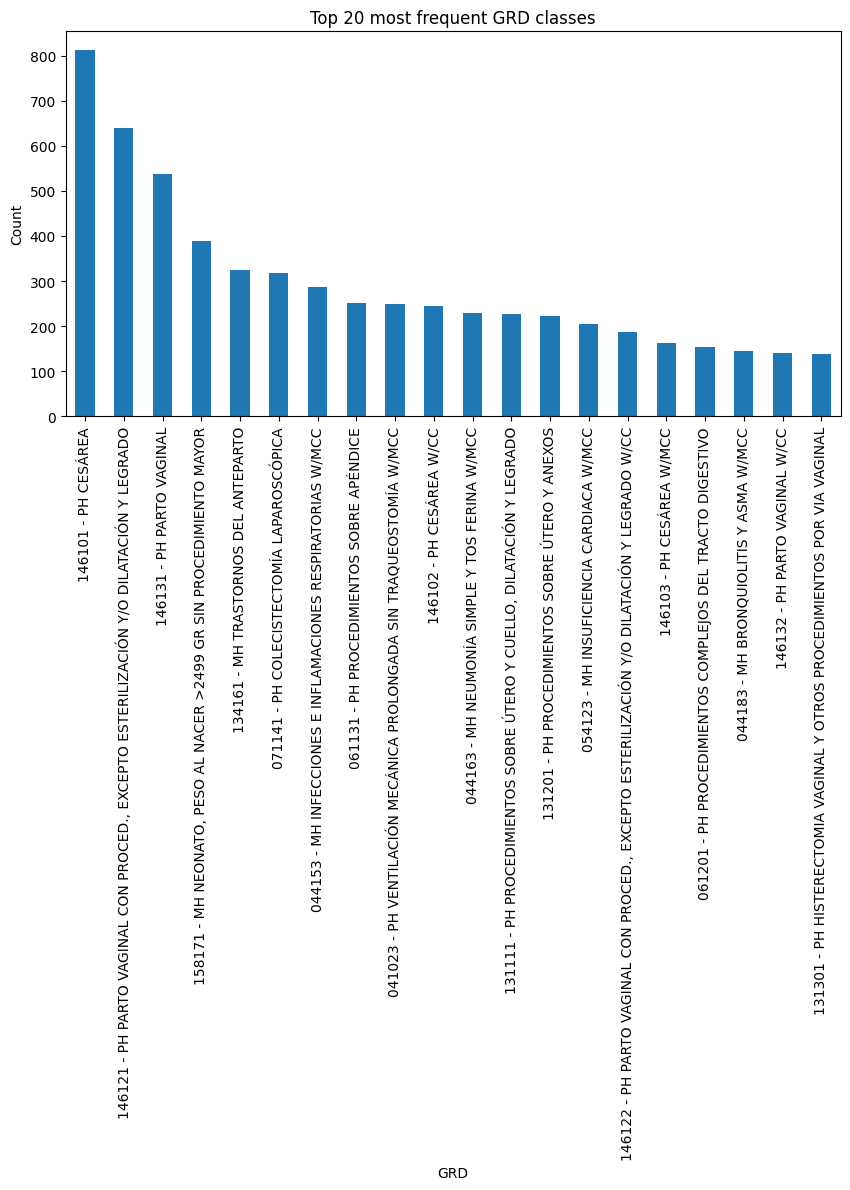

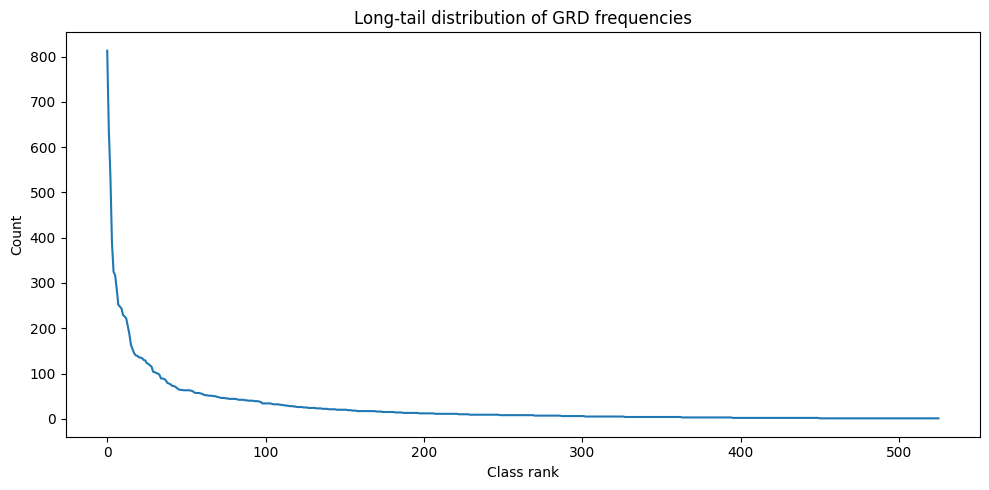

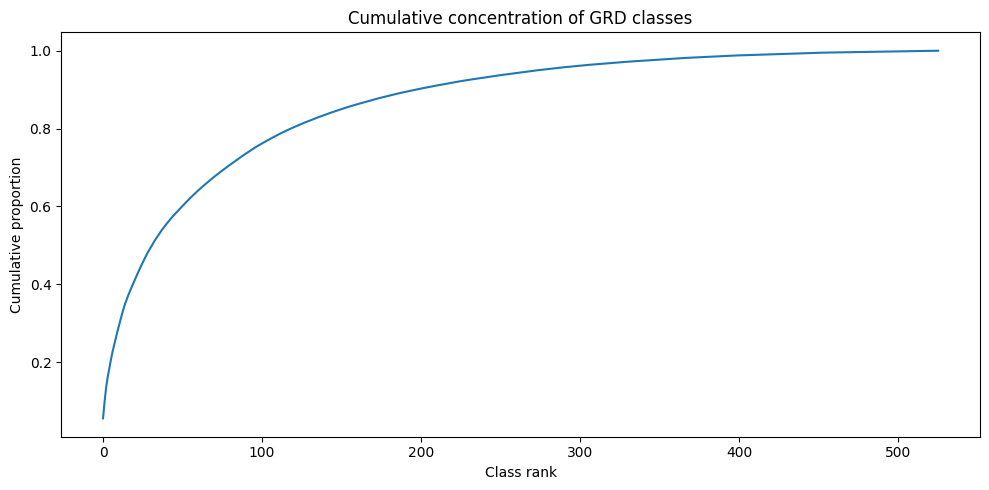

In [7]:

# Figures used in the report
fig, ax = plt.subplots(figsize=(10, 5))
raw_grd_counts.head(20).plot(kind="bar", ax=ax)
ax.set_title("Top 20 most frequent GRD classes")
ax.set_xlabel("GRD")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "grd_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
raw_grd_counts.reset_index(drop=True).plot(ax=ax)
ax.set_title("Long-tail distribution of GRD frequencies")
ax.set_xlabel("Class rank")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "long_tail.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
(raw_grd_counts.cumsum() / raw_grd_counts.sum()).reset_index(drop=True).plot(ax=ax)
ax.set_title("Cumulative concentration of GRD classes")
ax.set_xlabel("Class rank")
ax.set_ylabel("Cumulative proportion")
plt.tight_layout()
plt.savefig(FIG_DIR / "cummulative.png", dpi=200, bbox_inches="tight")
plt.show()

In [8]:

# Diagnosis and procedure column audit
diag_cols_raw = [c for c in df.columns if "diag" in c.lower()]
proc_cols_raw = [c for c in df.columns if "proc" in c.lower() or "proced" in c.lower()]

print("Diagnosis columns:", len(diag_cols_raw))
print("Procedure columns:", len(proc_cols_raw))

if diag_cols_raw:
    display(df[diag_cols_raw[:5]].describe(include="all").T)
if proc_cols_raw:
    display(df[proc_cols_raw[:5]].describe(include="all").T)

print("Age summary:")
display(df[col_edad].describe())
print("Sex distribution:")
display(df[col_sexo].value_counts(dropna=False).to_frame("count"))

Diagnosis columns: 35
Procedure columns: 30


,count,unique,top,freq
Diag 01 Principal (cod+des),14561,1491,O70.0 - Desgarro perineal de primer grado dura...,779
Diag 02 Secundario (cod+des),14561,1717,-,1209
Diag 03 Secundario (cod+des),14561,1498,-,2687
Diag 04 Secundario (cod+des),14561,1304,-,4127
Diag 05 Secundario (cod+des),14561,1151,-,5371


,count,unique,top,freq
Proced 01 Principal (cod+des),14561,528,73.59 - PARTO ASISTIDO MANUALMENTE.OTRO,1648
Proced 02 Secundario (cod+des),14561,496,89.7 - EXAMEN FISICO GENERAL,1404
Proced 03 Secundario (cod+des),14561,385,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,1892
Proced 04 Secundario (cod+des),14561,287,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,1662
Proced 05 Secundario (cod+des),14561,259,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,1641


Age summary:


count    14561.000000
mean        39.426550
std         24.681545
min          0.000000
25%         23.000000
50%         36.000000
75%         60.000000
max        121.000000
Name: Edad en años, dtype: float64

Sex distribution:


,count
Sexo (Desc),
Mujer,9617
Hombre,4944


## 4. Data preprocessing

Clinical fields are converted to code-only values. Secondary missing markers are treated as explicit absence of information and encoded later as `UNK`.

In [9]:

def extract_code(value, missing_as_nan=True):
    if pd.isna(value):
        return np.nan if missing_as_nan else "UNK"
    text = str(value).strip().upper()
    if text in {"", "-", "NAN", "NONE", "NULL"}:
        return np.nan if missing_as_nan else "UNK"
    if " - " in text:
        return text.split(" - ", 1)[0].strip()
    return text.split()[0].strip()


def normalize_sex(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().upper()
    if text in {"HOMBRE", "MASCULINO", "MALE", "M"}:
        return 1
    if text in {"MUJER", "FEMENINO", "FEMALE", "F"}:
        return 0
    return np.nan


df_limpio = df.copy()

diag_cols = [c for c in df_limpio.columns if "diag" in c.lower()]
proc_cols = [c for c in df_limpio.columns if "proc" in c.lower() or "proced" in c.lower()]

for col in diag_cols:
    df_limpio[col] = df_limpio[col].apply(lambda x: extract_code(x, missing_as_nan=False))

for col in proc_cols:
    df_limpio[col] = df_limpio[col].apply(lambda x: extract_code(x, missing_as_nan=False))

df_limpio[col_grd] = df_limpio[col_grd].apply(lambda x: extract_code(x, missing_as_nan=True))
df_limpio[col_sexo] = df_limpio[col_sexo].apply(normalize_sex)
df_limpio[col_edad] = pd.to_numeric(df_limpio[col_edad], errors="coerce")

required_after_clean = [col_grd, col_edad, col_sexo]
df_limpio = df_limpio.dropna(subset=required_after_clean).copy()
df_limpio[col_sexo] = df_limpio[col_sexo].astype(int)

print("Clean dataset shape:", df_limpio.shape)
display(df_limpio[[col_grd, col_edad, col_sexo]].head())

Clean dataset shape: (14561, 68)


,GRD,Edad en años,Sexo (Desc)
0,184103,40,1
1,041013,53,1
2,041013,65,1
3,041023,61,1
4,041023,30,1


## 5. Target filtering and final modeling dataset

Classes with fewer than 30 observations are excluded to preserve stratified splitting and meaningful evaluation.

In [10]:

gr_counts = df_limpio[col_grd].value_counts()
selected_classes = gr_counts[gr_counts >= TARGET_THRESHOLD].index

df_modelo = df_limpio[df_limpio[col_grd].isin(selected_classes)].copy()

final_counts = df_modelo[col_grd].value_counts()
print("Target threshold:", TARGET_THRESHOLD)
print("Final dataset shape:", df_modelo.shape)
print("Final GRD classes:", final_counts.shape[0])
print("Minimum class support:", final_counts.min())
print("Maximum class support:", final_counts.max())
display(final_counts.head(10).to_frame("count"))

Target threshold: 30
Final dataset shape: (11480, 68)
Final GRD classes: 113
Minimum class support: 30
Maximum class support: 813


,count
GRD,
146101,813
146121,639
146131,538
158171,389
134161,325
071141,317
044153,287
061131,252
041023,248


## 6. Pipeline diagnostics

These checks verify that the final notebook contains the required elements for a reproducible report.

In [11]:

def natural_key(text):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", str(text))]

cols_diag = sorted([c for c in df_modelo.columns if "diag" in c.lower()], key=natural_key)
cols_proc = sorted([c for c in df_modelo.columns if "proc" in c.lower() or "proced" in c.lower()], key=natural_key)

col_diag_principal = [c for c in cols_diag if "principal" in c.lower()][0]
col_proc_principal = [c for c in cols_proc if "principal" in c.lower()][0]
cols_diag_sec = [c for c in cols_diag if c != col_diag_principal]
cols_proc_sec = [c for c in cols_proc if c != col_proc_principal]

checks = {
    "01_dataset_loaded": df.shape[0] > 0 and df.shape[1] > 0,
    "02_target_exists": col_grd in df_modelo.columns,
    "03_age_exists": col_edad in df_modelo.columns,
    "04_sex_exists": col_sexo in df_modelo.columns,
    "05_diag_principal_detected": isinstance(col_diag_principal, str),
    "06_proc_principal_detected": isinstance(col_proc_principal, str),
    "07_secondary_diag_available": len(cols_diag_sec) >= 16,
    "08_secondary_proc_available": len(cols_proc_sec) >= 24,
    "09_min_class_support_ok": df_modelo[col_grd].value_counts().min() >= TARGET_THRESHOLD,
    "10_multiclass_problem": df_modelo[col_grd].nunique() > 2,
}

for name, passed in checks.items():
    print(f"{name}: {'OK' if passed else 'FAIL'}")

if not all(checks.values()):
    raise ValueError("At least one required pipeline diagnostic failed.")

print("Diagnosis principal:", col_diag_principal)
print("Procedure principal:", col_proc_principal)
print("Secondary diagnosis columns:", len(cols_diag_sec))
print("Secondary procedure columns:", len(cols_proc_sec))

01_dataset_loaded: OK
02_target_exists: OK
03_age_exists: OK
04_sex_exists: OK
05_diag_principal_detected: OK
06_proc_principal_detected: OK
07_secondary_diag_available: OK
08_secondary_proc_available: OK
09_min_class_support_ok: OK
10_multiclass_problem: OK
Diagnosis principal: Diag 01 Principal (cod+des)
Procedure principal: Proced 01 Principal (cod+des)
Secondary diagnosis columns: 34
Secondary procedure columns: 29


## 7. Shared split and helper functions

In [12]:

y_raw = df_modelo[col_grd].astype(str)
le_target = LabelEncoder()
y_all = le_target.fit_transform(y_raw)

train_idx, test_idx = train_test_split(
    df_modelo.index,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_all,
)

print("Train rows:", len(train_idx))
print("Test rows:", len(test_idx))
print("Classes:", len(le_target.classes_))


def safe_layer_name(name):
    text = str(name).strip().lower()
    text = re.sub(r"[^a-zA-Z0-9_]+", "_", text)
    text = re.sub(r"_+", "_", text).strip("_")
    return text


def encode_feature_train_test(train_series, test_series):
    train_values = train_series.fillna("UNK").astype(str)
    test_values = test_series.fillna("UNK").astype(str)
    unique_train = pd.Series(pd.concat([train_values, pd.Series(["UNK"])]).unique())
    le = LabelEncoder()
    le.fit(unique_train.astype(str))
    known = set(le.classes_)
    test_values = test_values.where(test_values.isin(known), "UNK")
    return le.transform(train_values), le.transform(test_values), le


def compute_top3_sparse(y_true, y_proba):
    return float(tf.keras.metrics.sparse_top_k_categorical_accuracy(y_true, y_proba, k=3).numpy().mean())

Train rows: 9184
Test rows: 2296
Classes: 113


## 8. Neural-network feature-combination search

This search evaluates different numbers of secondary diagnosis and procedure fields using a fixed embedding-based neural network. Macro-F1 is used as the main selection metric.

In [13]:

n_diag_grid = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, min(34, len(cols_diag_sec))]
n_diag_grid = sorted(set([x for x in n_diag_grid if x <= len(cols_diag_sec)]))

n_proc_grid = [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, min(29, len(cols_proc_sec))]
n_proc_grid = sorted(set([x for x in n_proc_grid if x <= len(cols_proc_sec)]))

NN_SEARCH_CSV = OUTPUT_DIR / "nn_feature_search_results.csv"
NN_SEARCH_EPOCHS = 12

print("Diagnosis grid:", n_diag_grid)
print("Procedure grid:", n_proc_grid)
print("Total NN feature combinations:", len(n_diag_grid) * len(n_proc_grid))

Diagnosis grid: [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 28, 34]
Procedure grid: [0, 2, 4, 6, 8, 10, 12, 16, 20, 24, 29]
Total NN feature combinations: 132


In [14]:

def prepare_nn_inputs(n_diag_sec, n_proc_sec, emb_diag_cap=24, emb_proc_cap=20):
    diag_selected = [col_diag_principal] + cols_diag_sec[:n_diag_sec]
    proc_selected = [col_proc_principal] + cols_proc_sec[:n_proc_sec]
    selected_code_cols = diag_selected + proc_selected

    train_df = df_modelo.loc[train_idx].copy()
    test_df = df_modelo.loc[test_idx].copy()

    encoders = {}
    x_train = {}
    x_test = {}
    input_specs = []

    for col in diag_selected:
        tr, te, le = encode_feature_train_test(train_df[col], test_df[col])
        encoders[col] = le
        safe = safe_layer_name(col)
        x_train[f"{safe}_input"] = tr
        x_test[f"{safe}_input"] = te
        vocab_size = len(le.classes_)
        emb_dim = min(emb_diag_cap, max(8, vocab_size // 60))
        input_specs.append((col, safe, vocab_size, emb_dim, "diag"))

    for col in proc_selected:
        tr, te, le = encode_feature_train_test(train_df[col], test_df[col])
        encoders[col] = le
        safe = safe_layer_name(col)
        x_train[f"{safe}_input"] = tr
        x_test[f"{safe}_input"] = te
        vocab_size = len(le.classes_)
        emb_dim = min(emb_proc_cap, max(8, vocab_size // 40))
        input_specs.append((col, safe, vocab_size, emb_dim, "proc"))

    scaler = StandardScaler()
    x_train["edad_input"] = scaler.fit_transform(train_df[[col_edad]]).reshape(-1)
    x_test["edad_input"] = scaler.transform(test_df[[col_edad]]).reshape(-1)
    x_train["sexo_input"] = train_df[col_sexo].astype(float).values
    x_test["sexo_input"] = test_df[col_sexo].astype(float).values

    y_train_local = le_target.transform(train_df[col_grd].astype(str))
    y_test_local = le_target.transform(test_df[col_grd].astype(str))

    metadata = {
        "diag_selected": diag_selected,
        "proc_selected": proc_selected,
        "input_specs": input_specs,
        "encoders": encoders,
        "scaler": scaler,
    }

    return x_train, x_test, y_train_local, y_test_local, metadata


def build_embedding_nn(input_specs, dense_layers=(256, 128), dropouts=(0.35, 0.25), learning_rate=1e-3, l2_value=0.0):
    inputs = []
    representations = []

    for _, safe, vocab_size, emb_dim, _ in input_specs:
        inp = keras.Input(shape=(1,), name=f"{safe}_input")
        emb = layers.Embedding(input_dim=vocab_size, output_dim=emb_dim, name=f"{safe}_embedding")(inp)
        emb = layers.Flatten(name=f"{safe}_flatten")(emb)
        inputs.append(inp)
        representations.append(emb)

    edad_input = keras.Input(shape=(1,), name="edad_input")
    sexo_input = keras.Input(shape=(1,), name="sexo_input")
    inputs.extend([edad_input, sexo_input])

    x = layers.Concatenate(name="feature_concatenation")(representations + [edad_input, sexo_input])

    for i, units in enumerate(dense_layers):
        x = layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=regularizers.l2(l2_value),
            name=f"dense_{i+1}",
        )(x)
        if dropouts[i] > 0:
            x = layers.Dropout(dropouts[i], name=f"dropout_{i+1}")(x)

    output = layers.Dense(len(le_target.classes_), activation="softmax", name="grd_output")(x)
    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [15]:

def run_single_nn_feature_search(n_diag_sec, n_proc_sec):
    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(SEED)
    start = time.time()

    x_train_local, x_test_local, y_train_local, y_test_local, metadata = prepare_nn_inputs(
        n_diag_sec=n_diag_sec,
        n_proc_sec=n_proc_sec,
    )

    model = build_embedding_nn(
        metadata["input_specs"],
        dense_layers=(256, 128),
        dropouts=(0.35, 0.25),
        learning_rate=1e-3,
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]

    history = model.fit(
        x=x_train_local,
        y=y_train_local,
        validation_split=VALIDATION_SPLIT,
        epochs=NN_SEARCH_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    y_proba = model.predict(x_test_local, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    return {
        "model_family": "Neural Network",
        "n_diag_sec": n_diag_sec,
        "n_proc_sec": n_proc_sec,
        "dense_layers": "[256, 128]",
        "dropouts": "[0.35, 0.25]",
        "accuracy": accuracy_score(y_test_local, y_pred),
        "macro_f1": f1_score(y_test_local, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test_local, y_pred, average="weighted"),
        "top3_accuracy": compute_top3_sparse(y_test_local, y_proba),
        "epochs_run": len(history.history["loss"]),
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "seconds": round(time.time() - start, 2),
    }


def run_nn_feature_search(force=False):
    if NN_SEARCH_CSV.exists() and not force:
        return pd.read_csv(NN_SEARCH_CSV)

    results = []
    for n_diag in n_diag_grid:
        for n_proc in n_proc_grid:
            print(f"NN feature search: diag={n_diag}, proc={n_proc}")
            result = run_single_nn_feature_search(n_diag, n_proc)
            results.append(result)
            pd.DataFrame(results).sort_values(
                by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
            ).to_csv(NN_SEARCH_CSV, index=False)

    return pd.read_csv(NN_SEARCH_CSV)

nn_feature_results = run_nn_feature_search(force=False)
nn_feature_results = nn_feature_results.sort_values(
    by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
).reset_index(drop=True)

display(nn_feature_results.head(10))

,model_family,n_diag_sec,n_proc_sec,dense_layers,dropouts,accuracy,macro_f1,weighted_f1,top3_accuracy,epochs_run,best_val_loss,seconds
0,Neural Network,16,10,"[256, 128]","[0.35, 0.25]",0.837979,0.766373,0.834693,0.949042,12,0.616918,10.54
1,Neural Network,16,20,"[256, 128]","[0.35, 0.25]",0.833624,0.761396,0.828283,0.947735,12,0.609659,12.99
2,Neural Network,24,2,"[256, 128]","[0.35, 0.25]",0.828833,0.758272,0.823951,0.949477,12,0.662763,10.32
3,Neural Network,10,12,"[256, 128]","[0.35, 0.25]",0.824477,0.758205,0.818041,0.949477,12,0.647578,9.42
4,Neural Network,16,6,"[256, 128]","[0.35, 0.25]",0.828397,0.756592,0.822309,0.950784,12,0.652959,9.50
5,Neural Network,34,12,"[256, 128]","[0.35, 0.25]",0.825348,0.754663,0.821510,0.948606,12,0.661164,15.41
6,Neural Network,28,16,"[256, 128]","[0.35, 0.25]",0.821429,0.753853,0.817747,0.947735,12,0.631936,14.63
7,Neural Network,20,8,"[256, 128]","[0.35, 0.25]",0.824042,0.753746,0.818528,0.956010,12,0.610124,10.89
8,Neural Network,20,2,"[256, 128]","[0.35, 0.25]",0.826655,0.753683,0.822131,0.944686,12,0.683709,9.45
9,Neural Network,20,16,"[256, 128]","[0.35, 0.25]",0.827526,0.752513,0.821046,0.944251,12,0.630093,12.46


## 9. Final neural-network experiments

The final neural-network candidates use the best feature configuration found above. The model list includes at least ten defendable variants and explicitly includes the architecture described in the report: one dense layer with 512 units, dropout 0.35, and class weights.

In [16]:

best_nn_feature = nn_feature_results.iloc[0]
BEST_N_DIAG_SEC = int(best_nn_feature["n_diag_sec"])
BEST_N_PROC_SEC = int(best_nn_feature["n_proc_sec"])

print("Best NN feature configuration:")
print(best_nn_feature)

Best NN feature configuration:
model_family     Neural Network
n_diag_sec                   16
n_proc_sec                   10
dense_layers         [256, 128]
dropouts           [0.35, 0.25]
accuracy               0.837979
macro_f1               0.766373
weighted_f1            0.834693
top3_accuracy          0.949042
epochs_run                   12
best_val_loss          0.616918
seconds                   10.54
Name: 0, dtype: object


In [17]:

def smooth_class_weights(y, alpha=0.50):
    counts = Counter(y)
    max_freq = max(counts.values())
    return {cls: (max_freq / freq) ** alpha for cls, freq in counts.items()}


def focal_loss_sparse(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -y_true_oh * tf.math.log(y_pred)
        weights = alpha * tf.pow(1.0 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weights * ce, axis=1))
    return loss_fn

final_nn_candidates = [
    {"name": "NN_baseline_256_128", "dense_layers": (256, 128), "dropouts": (0.35, 0.25), "emb_diag": 24, "emb_proc": 20, "loss": "ce", "class_weight": None, "l2": 0.0},
    {"name": "NN_report_512_cw", "dense_layers": (512,), "dropouts": (0.35,), "emb_diag": 24, "emb_proc": 20, "loss": "ce", "class_weight": "balanced", "l2": 0.0},
    {"name": "NN_256", "dense_layers": (256,), "dropouts": (0.30,), "emb_diag": 24, "emb_proc": 20, "loss": "ce", "class_weight": None, "l2": 0.0},
    {"name": "NN_256_cw_smooth", "dense_layers": (256,), "dropouts": (0.30,), "emb_diag": 24, "emb_proc": 20, "loss": "ce", "class_weight": "smooth", "l2": 0.0},
    {"name": "NN_512", "dense_layers": (512,), "dropouts": (0.35,), "emb_diag": 24, "emb_proc": 20, "loss": "ce", "class_weight": None, "l2": 0.0},
    {"name": "NN_512_cw_smooth", "dense_layers": (512,), "dropouts": (0.35,), "emb_diag": 24, "emb_proc": 20, "loss": "ce", "class_weight": "smooth", "l2": 0.0},
    {"name": "NN_embeddings_32_32", "dense_layers": (256,), "dropouts": (0.30,), "emb_diag": 32, "emb_proc": 32, "loss": "ce", "class_weight": None, "l2": 0.0},
    {"name": "NN_embeddings_32_32_cw", "dense_layers": (256,), "dropouts": (0.30,), "emb_diag": 32, "emb_proc": 32, "loss": "ce", "class_weight": "smooth", "l2": 0.0},
    {"name": "NN_focal", "dense_layers": (256,), "dropouts": (0.30,), "emb_diag": 24, "emb_proc": 20, "loss": "focal", "class_weight": None, "l2": 0.0},
    {"name": "NN_focal_embeddings", "dense_layers": (256,), "dropouts": (0.30,), "emb_diag": 32, "emb_proc": 32, "loss": "focal", "class_weight": None, "l2": 0.0},
    {"name": "NN_l2", "dense_layers": (256,), "dropouts": (0.25,), "emb_diag": 32, "emb_proc": 32, "loss": "ce", "class_weight": None, "l2": 1e-4},
    {"name": "NN_256_128_focal", "dense_layers": (256, 128), "dropouts": (0.30, 0.20), "emb_diag": 32, "emb_proc": 32, "loss": "focal", "class_weight": None, "l2": 0.0},
]

pd.DataFrame(final_nn_candidates)

,name,dense_layers,dropouts,emb_diag,emb_proc,loss,class_weight,l2
0,NN_baseline_256_128,"(256, 128)","(0.35, 0.25)",24,20,ce,NaN,0.0000
1,NN_report_512_cw,"(512,)","(0.35,)",24,20,ce,balanced,0.0000
2,NN_256,"(256,)","(0.3,)",24,20,ce,NaN,0.0000
3,NN_256_cw_smooth,"(256,)","(0.3,)",24,20,ce,smooth,0.0000
4,NN_512,"(512,)","(0.35,)",24,20,ce,NaN,0.0000
5,NN_512_cw_smooth,"(512,)","(0.35,)",24,20,ce,smooth,0.0000
6,NN_embeddings_32_32,"(256,)","(0.3,)",32,32,ce,NaN,0.0000
7,NN_embeddings_32_32_cw,"(256,)","(0.3,)",32,32,ce,smooth,0.0000
8,NN_focal,"(256,)","(0.3,)",24,20,focal,NaN,0.0000
9,NN_focal_embeddings,"(256,)","(0.3,)",32,32,focal,NaN,0.0000


In [18]:

FINAL_NN_CSV = OUTPUT_DIR / "final_neural_network_results.csv"
FINAL_NN_EPOCHS = 40


def run_final_nn_candidate(candidate, force=False):
    x_train_local, x_test_local, y_train_local, y_test_local, metadata = prepare_nn_inputs(
        n_diag_sec=BEST_N_DIAG_SEC,
        n_proc_sec=BEST_N_PROC_SEC,
        emb_diag_cap=candidate["emb_diag"],
        emb_proc_cap=candidate["emb_proc"],
    )

    tf.keras.backend.clear_session()
    gc.collect()
    tf.keras.utils.set_random_seed(SEED)

    model = build_embedding_nn(
        metadata["input_specs"],
        dense_layers=candidate["dense_layers"],
        dropouts=candidate["dropouts"],
        learning_rate=1e-3,
        l2_value=candidate["l2"],
    )

    if candidate["loss"] == "focal":
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss=focal_loss_sparse(),
            metrics=["accuracy"],
        )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
    ]

    fit_kwargs = dict(
        x=x_train_local,
        y=y_train_local,
        validation_split=VALIDATION_SPLIT,
        epochs=FINAL_NN_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    if candidate["class_weight"] == "balanced":
        classes = np.unique(y_train_local)
        weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_local)
        fit_kwargs["class_weight"] = dict(zip(classes, weights))
    elif candidate["class_weight"] == "smooth":
        fit_kwargs["class_weight"] = smooth_class_weights(y_train_local, alpha=0.50)

    start = time.time()
    history = model.fit(**fit_kwargs)
    y_proba = model.predict(x_test_local, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)

    result = {
        "model": candidate["name"],
        "model_family": "Neural Network",
        "n_diag_sec": BEST_N_DIAG_SEC,
        "n_proc_sec": BEST_N_PROC_SEC,
        "dense_layers": str(candidate["dense_layers"]),
        "dropouts": str(candidate["dropouts"]),
        "emb_diag": candidate["emb_diag"],
        "emb_proc": candidate["emb_proc"],
        "loss": candidate["loss"],
        "class_weight": str(candidate["class_weight"]),
        "l2": candidate["l2"],
        "accuracy": accuracy_score(y_test_local, y_pred),
        "macro_f1": f1_score(y_test_local, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test_local, y_pred, average="weighted"),
        "macro_precision": precision_score(y_test_local, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test_local, y_pred, average="macro", zero_division=0),
        "top3_accuracy": compute_top3_sparse(y_test_local, y_proba),
        "epochs_run": len(history.history["loss"]),
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "seconds": round(time.time() - start, 2),
    }

    return result, model, history, (x_train_local, x_test_local, y_train_local, y_test_local, metadata)


def run_final_nn_experiments(force=False):
    if FINAL_NN_CSV.exists() and not force:
        return pd.read_csv(FINAL_NN_CSV)

    results = []
    for candidate in final_nn_candidates:
        print("Training", candidate["name"])
        result, _, _, _ = run_final_nn_candidate(candidate)
        results.append(result)
        pd.DataFrame(results).sort_values(
            by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
        ).to_csv(FINAL_NN_CSV, index=False)

    return pd.read_csv(FINAL_NN_CSV)

final_nn_results = run_final_nn_experiments(force=False)
final_nn_results = final_nn_results.sort_values(
    by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
).reset_index(drop=True)

display(final_nn_results)

,model,model_family,n_diag_sec,n_proc_sec,dense_layers,dropouts,emb_diag,emb_proc,loss,class_weight,l2,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,top3_accuracy,epochs_run,best_val_loss,seconds
0,NN_l2,Neural Network,16,10,"(256,)","(0.25,)",32,32,ce,NaN,0.0001,0.852787,0.796384,0.848814,0.822049,0.792127,0.961672,40,0.595829,21.17
1,NN_512_cw_smooth,Neural Network,16,10,"(512,)","(0.35,)",24,20,ce,smooth,0.0000,0.838850,0.781005,0.836175,0.798404,0.782076,0.962544,20,0.532603,14.49
2,NN_focal,Neural Network,16,10,"(256,)","(0.3,)",24,20,focal,NaN,0.0000,0.841463,0.780419,0.838636,0.803373,0.777723,0.963850,24,0.079089,15.06
3,NN_focal_embeddings,Neural Network,16,10,"(256,)","(0.3,)",32,32,focal,NaN,0.0000,0.841463,0.780419,0.838636,0.803373,0.777723,0.963850,24,0.079089,15.15
4,NN_256,Neural Network,16,10,"(256,)","(0.3,)",24,20,ce,NaN,0.0000,0.841463,0.779113,0.836910,0.807348,0.774638,0.960801,20,0.538944,12.90
5,NN_embeddings_32_32,Neural Network,16,10,"(256,)","(0.3,)",32,32,ce,NaN,0.0000,0.841463,0.779113,0.836910,0.807348,0.774638,0.960801,20,0.538944,12.96
6,NN_512,Neural Network,16,10,"(512,)","(0.35,)",24,20,ce,NaN,0.0000,0.837979,0.778613,0.834747,0.808516,0.773766,0.960801,20,0.543540,14.50
7,NN_report_512_cw,Neural Network,16,10,"(512,)","(0.35,)",24,20,ce,balanced,0.0000,0.831010,0.778295,0.830564,0.791849,0.784250,0.963850,23,0.559700,16.20
8,NN_256_cw_smooth,Neural Network,16,10,"(256,)","(0.3,)",24,20,ce,smooth,0.0000,0.833188,0.769024,0.830438,0.785688,0.771324,0.962108,20,0.545046,13.57
9,NN_embeddings_32_32_cw,Neural Network,16,10,"(256,)","(0.3,)",32,32,ce,smooth,0.0000,0.833188,0.769024,0.830438,0.785688,0.771324,0.962108,20,0.545046,12.93


## 10. Random Forest feature search and final experiments

In [19]:

def group_diag_code(value):
    text = str(value).upper().strip()
    if text in {"", "-", "NAN", "NONE", "NULL"}:
        return "UNK"
    return text[:3]


def group_proc_code(value):
    text = str(value).upper().strip().replace(".", "")
    if text in {"", "-", "NAN", "NONE", "NULL"}:
        return "UNK"
    return text[:2]


def prepare_rf_table(n_diag_sec, n_proc_sec):
    diag_selected = [col_diag_principal] + cols_diag_sec[:n_diag_sec]
    proc_selected = [col_proc_principal] + cols_proc_sec[:n_proc_sec]

    train_df = df_modelo.loc[train_idx].copy()
    test_df = df_modelo.loc[test_idx].copy()

    X_train = pd.DataFrame(index=train_df.index)
    X_test = pd.DataFrame(index=test_df.index)

    for col in diag_selected:
        tr = train_df[col].fillna("UNK").astype(str).map(group_diag_code)
        te = test_df[col].fillna("UNK").astype(str).map(group_diag_code)
        tr_enc, te_enc, _ = encode_feature_train_test(tr, te)
        X_train[col] = tr_enc
        X_test[col] = te_enc

    for col in proc_selected:
        tr = train_df[col].fillna("UNK").astype(str).map(group_proc_code)
        te = test_df[col].fillna("UNK").astype(str).map(group_proc_code)
        tr_enc, te_enc, _ = encode_feature_train_test(tr, te)
        X_train[col] = tr_enc
        X_test[col] = te_enc

    scaler = StandardScaler()
    X_train[col_edad] = scaler.fit_transform(train_df[[col_edad]]).reshape(-1)
    X_test[col_edad] = scaler.transform(test_df[[col_edad]]).reshape(-1)
    X_train[col_sexo] = train_df[col_sexo].astype(int).values
    X_test[col_sexo] = test_df[col_sexo].astype(int).values

    y_train_local = le_target.transform(train_df[col_grd].astype(str))
    y_test_local = le_target.transform(test_df[col_grd].astype(str))

    return X_train, X_test, y_train_local, y_test_local

RF_SEARCH_CSV = OUTPUT_DIR / "rf_feature_search_results.csv"

In [20]:

def evaluate_rf_model(model, X_test, y_test_local):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    return {
        "accuracy": accuracy_score(y_test_local, y_pred),
        "macro_f1": f1_score(y_test_local, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test_local, y_pred, average="weighted"),
        "macro_precision": precision_score(y_test_local, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test_local, y_pred, average="macro", zero_division=0),
        "top3_accuracy": top_k_accuracy_score(
            y_test_local,
            y_proba,
            k=3,
            labels=np.arange(len(le_target.classes_)),
        ),
    }


def run_single_rf_feature_search(n_diag_sec, n_proc_sec):
    start = time.time()
    X_train_local, X_test_local, y_train_local, y_test_local = prepare_rf_table(n_diag_sec, n_proc_sec)
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED,
    )
    model.fit(X_train_local, y_train_local)
    metrics = evaluate_rf_model(model, X_test_local, y_test_local)
    metrics.update({
        "model_family": "Random Forest",
        "n_diag_sec": n_diag_sec,
        "n_proc_sec": n_proc_sec,
        "main_hyperparameters": "300 trees, balanced_subsample, sqrt features",
        "seconds": round(time.time() - start, 2),
    })
    return metrics


def run_rf_feature_search(force=False):
    if RF_SEARCH_CSV.exists() and not force:
        return pd.read_csv(RF_SEARCH_CSV)

    results = []
    for n_diag in n_diag_grid:
        for n_proc in n_proc_grid:
            print(f"RF feature search: diag={n_diag}, proc={n_proc}")
            result = run_single_rf_feature_search(n_diag, n_proc)
            results.append(result)
            pd.DataFrame(results).sort_values(
                by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
            ).to_csv(RF_SEARCH_CSV, index=False)

    return pd.read_csv(RF_SEARCH_CSV)

rf_feature_results = run_rf_feature_search(force=False)
rf_feature_results = rf_feature_results.sort_values(
    by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
).reset_index(drop=True)

display(rf_feature_results.head(10))

,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,top3_accuracy,model_family,n_diag_sec,n_proc_sec,main_hyperparameters,seconds
0,0.699477,0.613882,0.693957,0.629920,0.621904,0.926829,Random Forest,6,0,"300 trees, balanced_subsample, sqrt features",1.49
1,0.693815,0.611350,0.689129,0.635585,0.615603,0.918990,Random Forest,12,0,"300 trees, balanced_subsample, sqrt features",1.50
2,0.689460,0.606549,0.682003,0.622431,0.613114,0.926829,Random Forest,4,2,"300 trees, balanced_subsample, sqrt features",1.40
3,0.687282,0.603767,0.679534,0.620640,0.611197,0.924652,Random Forest,12,2,"300 trees, balanced_subsample, sqrt features",1.53
4,0.689895,0.602830,0.681309,0.616592,0.613658,0.929878,Random Forest,10,2,"300 trees, balanced_subsample, sqrt features",1.50
5,0.694686,0.601247,0.688908,0.630903,0.607889,0.912892,Random Forest,10,0,"300 trees, balanced_subsample, sqrt features",1.44
6,0.692073,0.601145,0.685081,0.626275,0.605532,0.917683,Random Forest,8,0,"300 trees, balanced_subsample, sqrt features",1.39
7,0.681620,0.597003,0.672344,0.614213,0.607132,0.924216,Random Forest,6,2,"300 trees, balanced_subsample, sqrt features",1.41
8,0.677700,0.594929,0.668505,0.611043,0.602214,0.918554,Random Forest,8,2,"300 trees, balanced_subsample, sqrt features",1.47
9,0.682056,0.591015,0.670419,0.614202,0.598141,0.928136,Random Forest,6,6,"300 trees, balanced_subsample, sqrt features",1.50


In [21]:

best_rf_feature = rf_feature_results.iloc[0]
BEST_RF_N_DIAG_SEC = int(best_rf_feature["n_diag_sec"])
BEST_RF_N_PROC_SEC = int(best_rf_feature["n_proc_sec"])

rf_candidates = [
    {"name": "RF_300_balanced", "n_estimators": 300, "max_depth": None, "min_samples_leaf": 2, "min_samples_split": 4, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_500_balanced", "n_estimators": 500, "max_depth": None, "min_samples_leaf": 2, "min_samples_split": 4, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_depth20", "n_estimators": 400, "max_depth": 20, "min_samples_leaf": 2, "min_samples_split": 4, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_depth30", "n_estimators": 400, "max_depth": 30, "min_samples_leaf": 2, "min_samples_split": 4, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_leaf1", "n_estimators": 400, "max_depth": None, "min_samples_leaf": 1, "min_samples_split": 2, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_leaf3", "n_estimators": 400, "max_depth": None, "min_samples_leaf": 3, "min_samples_split": 6, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_log2", "n_estimators": 400, "max_depth": None, "min_samples_leaf": 2, "min_samples_split": 4, "max_features": "log2", "class_weight": "balanced_subsample"},
    {"name": "RF_no_weight", "n_estimators": 400, "max_depth": None, "min_samples_leaf": 2, "min_samples_split": 4, "max_features": "sqrt", "class_weight": None},
    {"name": "RF_depth15_leaf1", "n_estimators": 500, "max_depth": 15, "min_samples_leaf": 1, "min_samples_split": 2, "max_features": "sqrt", "class_weight": "balanced_subsample"},
    {"name": "RF_depth25_leaf1", "n_estimators": 500, "max_depth": 25, "min_samples_leaf": 1, "min_samples_split": 2, "max_features": "sqrt", "class_weight": "balanced_subsample"},
]

FINAL_RF_CSV = OUTPUT_DIR / "final_random_forest_results.csv"

In [22]:

def run_final_rf_experiments(force=False):
    if FINAL_RF_CSV.exists() and not force:
        return pd.read_csv(FINAL_RF_CSV)

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = prepare_rf_table(BEST_RF_N_DIAG_SEC, BEST_RF_N_PROC_SEC)
    results = []

    for cfg in rf_candidates:
        print("Training", cfg["name"])
        start = time.time()
        model = RandomForestClassifier(
            n_estimators=cfg["n_estimators"],
            max_depth=cfg["max_depth"],
            min_samples_leaf=cfg["min_samples_leaf"],
            min_samples_split=cfg["min_samples_split"],
            max_features=cfg["max_features"],
            class_weight=cfg["class_weight"],
            n_jobs=-1,
            random_state=SEED,
        )
        model.fit(X_train_rf, y_train_rf)
        metrics = evaluate_rf_model(model, X_test_rf, y_test_rf)
        metrics.update({
            "model": cfg["name"],
            "model_family": "Random Forest",
            "n_diag_sec": BEST_RF_N_DIAG_SEC,
            "n_proc_sec": BEST_RF_N_PROC_SEC,
            "n_estimators": cfg["n_estimators"],
            "max_depth": str(cfg["max_depth"]),
            "min_samples_leaf": cfg["min_samples_leaf"],
            "min_samples_split": cfg["min_samples_split"],
            "max_features": cfg["max_features"],
            "class_weight": str(cfg["class_weight"]),
            "seconds": round(time.time() - start, 2),
        })
        results.append(metrics)
        pd.DataFrame(results).sort_values(
            by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
        ).to_csv(FINAL_RF_CSV, index=False)

    return pd.read_csv(FINAL_RF_CSV)

final_rf_results = run_final_rf_experiments(force=False)
final_rf_results = final_rf_results.sort_values(
    by=["macro_f1", "accuracy", "weighted_f1"], ascending=False
).reset_index(drop=True)

display(final_rf_results)

,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,top3_accuracy,model,model_family,n_diag_sec,n_proc_sec,n_estimators,max_depth,min_samples_leaf,min_samples_split,max_features,class_weight,seconds
0,0.710801,0.619883,0.701956,0.645015,0.622555,0.926394,RF_depth15_leaf1,Random Forest,6,0,500,15.0,1,2,sqrt,balanced_subsample,2.25
1,0.704268,0.616684,0.697459,0.632472,0.624276,0.923780,RF_log2,Random Forest,6,0,400,NaN,2,4,log2,balanced_subsample,1.76
2,0.703833,0.616322,0.697025,0.632371,0.623914,0.923780,RF_depth30,Random Forest,6,0,400,30.0,2,4,sqrt,balanced_subsample,1.89
3,0.699477,0.613882,0.693957,0.629920,0.621904,0.926829,RF_300_balanced,Random Forest,6,0,300,NaN,2,4,sqrt,balanced_subsample,1.33
4,0.699042,0.611224,0.693022,0.628953,0.618395,0.925958,RF_500_balanced,Random Forest,6,0,500,NaN,2,4,sqrt,balanced_subsample,2.25
5,0.710801,0.610996,0.695264,0.639401,0.605527,0.932056,RF_depth25_leaf1,Random Forest,6,0,500,25.0,1,2,sqrt,balanced_subsample,2.54
6,0.705139,0.608147,0.688867,0.639349,0.601825,0.929443,RF_leaf1,Random Forest,6,0,400,NaN,1,2,sqrt,balanced_subsample,2.09
7,0.696429,0.604121,0.690023,0.618765,0.611860,0.925958,RF_depth20,Random Forest,6,0,400,20.0,2,4,sqrt,balanced_subsample,1.84
8,0.681620,0.600130,0.679352,0.616974,0.613332,0.922474,RF_leaf3,Random Forest,6,0,400,NaN,3,6,sqrt,balanced_subsample,1.85
9,0.696864,0.569211,0.674333,0.621896,0.560735,0.917247,RF_no_weight,Random Forest,6,0,400,NaN,2,4,sqrt,NaN,1.38


## 11. Final model comparison

In [23]:

best_nn = final_nn_results.iloc[0].copy()
best_rf = final_rf_results.iloc[0].copy()

comparison_rows = []
for row in [best_nn, best_rf]:
    comparison_rows.append({
        "Model": row.get("model", row.get("model_family")),
        "Family": row["model_family"],
        "Diag. sec": int(row["n_diag_sec"]),
        "Proc. sec": int(row["n_proc_sec"]),
        "Accuracy": row["accuracy"],
        "Macro-F1": row["macro_f1"],
        "Weighted-F1": row["weighted_f1"],
        "Top-3 Acc.": row["top3_accuracy"],
    })

final_comparison = pd.DataFrame(comparison_rows)
final_comparison = final_comparison.sort_values(by="Macro-F1", ascending=False).reset_index(drop=True)

display(final_comparison)
final_comparison.to_csv(OUTPUT_DIR / "final_model_comparison.csv", index=False)

,Model,Family,Diag. sec,Proc. sec,Accuracy,Macro-F1,Weighted-F1,Top-3 Acc.
0,NN_l2,Neural Network,16,10,0.852787,0.796384,0.848814,0.961672
1,RF_depth15_leaf1,Random Forest,6,0,0.710801,0.619883,0.701956,0.926394


In [24]:

# Combined top-10 table for the report
nn_top = final_nn_results.copy()
nn_top["Family"] = "Neural Network"
rf_top = final_rf_results.copy()
rf_top["Family"] = "Random Forest"

common_cols = [
    "Family", "model", "n_diag_sec", "n_proc_sec", "accuracy", "macro_f1",
    "weighted_f1", "top3_accuracy"
]
combined_top10 = pd.concat([
    nn_top.rename(columns={"model": "model"})[common_cols].head(5),
    rf_top.rename(columns={"model": "model"})[common_cols].head(5),
], axis=0).sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
combined_top10.insert(0, "Rank", np.arange(1, len(combined_top10) + 1))

display(combined_top10)
combined_top10.to_csv(OUTPUT_DIR / "top10_configurations_for_report.csv", index=False)

,Rank,Family,model,n_diag_sec,n_proc_sec,accuracy,macro_f1,weighted_f1,top3_accuracy
0,1,Neural Network,NN_l2,16,10,0.852787,0.796384,0.848814,0.961672
1,2,Neural Network,NN_512_cw_smooth,16,10,0.838850,0.781005,0.836175,0.962544
2,3,Neural Network,NN_focal,16,10,0.841463,0.780419,0.838636,0.963850
3,4,Neural Network,NN_focal_embeddings,16,10,0.841463,0.780419,0.838636,0.963850
4,5,Neural Network,NN_256,16,10,0.841463,0.779113,0.836910,0.960801
5,6,Random Forest,RF_depth15_leaf1,6,0,0.710801,0.619883,0.701956,0.926394
6,7,Random Forest,RF_log2,6,0,0.704268,0.616684,0.697459,0.923780
7,8,Random Forest,RF_depth30,6,0,0.703833,0.616322,0.697025,0.923780
8,9,Random Forest,RF_300_balanced,6,0,0.699477,0.613882,0.693957,0.926829
9,10,Random Forest,RF_500_balanced,6,0,0.699042,0.611224,0.693022,0.925958


## 12. Training curves and error analysis for the selected neural network

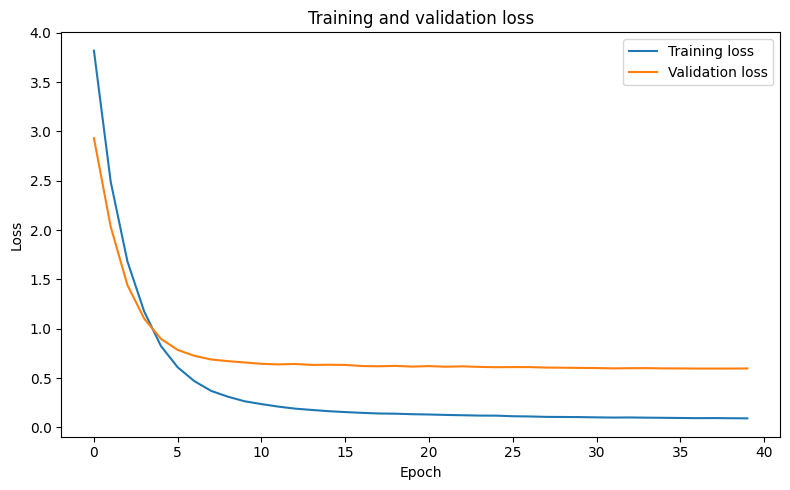

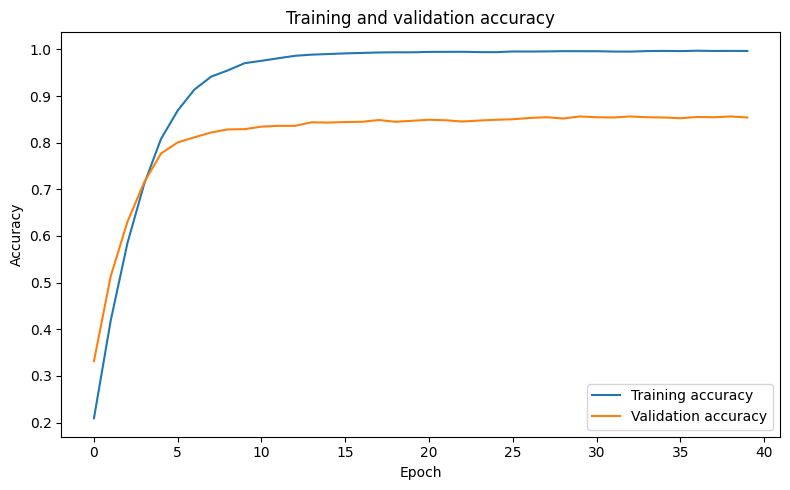

In [25]:

# Retrain the selected neural network candidate to store curves and prediction artifacts
selected_name = best_nn["model"]
selected_candidate = next(c for c in final_nn_candidates if c["name"] == selected_name)

selected_result, selected_model, selected_history, selected_data = run_final_nn_candidate(selected_candidate)
x_train_selected, x_test_selected, y_train_selected, y_test_selected, metadata_selected = selected_data

y_proba_selected = selected_model.predict(x_test_selected, verbose=0)
y_pred_selected = np.argmax(y_proba_selected, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(selected_history.history["loss"], label="Training loss")
ax.plot(selected_history.history["val_loss"], label="Validation loss")
ax.set_title("Training and validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_loss.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(selected_history.history["accuracy"], label="Training accuracy")
ax.plot(selected_history.history["val_accuracy"], label="Validation accuracy")
ax.set_title("Training and validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_metric.png", dpi=200, bbox_inches="tight")
plt.show()

In [26]:

# Classification report
report_dict = classification_report(
    y_test_selected,
    y_pred_selected,
    labels=np.arange(len(le_target.classes_)),
    target_names=le_target.classes_,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_df.to_csv(OUTPUT_DIR / "classification_report_selected_nn.csv")
display(report_df.head(15))

,precision,recall,f1-score,support
014141,0.588235,0.769231,0.666667,13.0
014142,0.785714,0.611111,0.687500,18.0
014143,0.733333,0.846154,0.785714,13.0
014221,1.000000,1.000000,1.000000,9.0
014241,1.000000,0.916667,0.956522,24.0
041013,0.857143,0.400000,0.545455,15.0
041023,0.795918,0.795918,0.795918,49.0
041203,0.913043,0.807692,0.857143,26.0
044113,1.000000,1.000000,1.000000,11.0
044123,1.000000,1.000000,1.000000,10.0


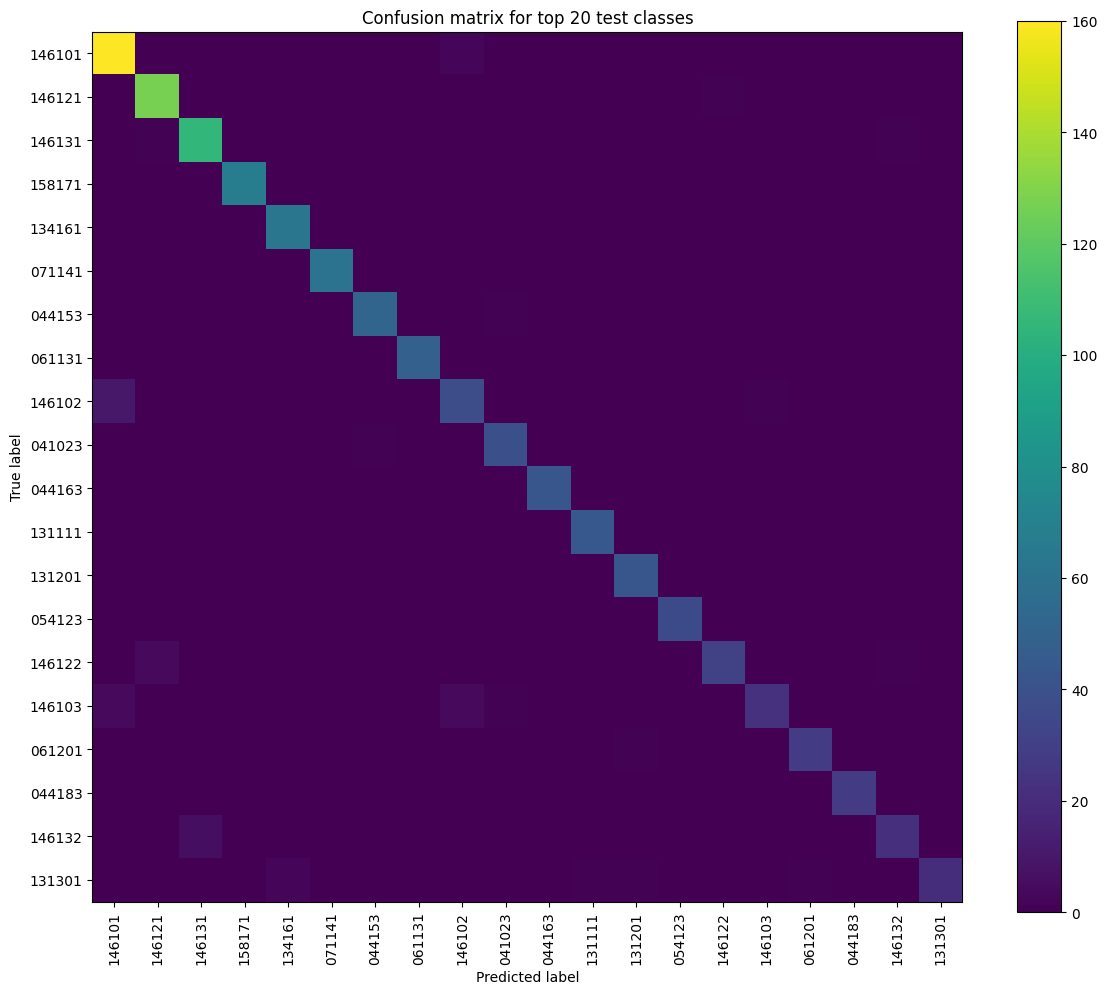

In [27]:

# Confusion matrix for the most frequent test classes
support_by_class = pd.Series(y_test_selected).value_counts().head(20).index.tolist()
cm = confusion_matrix(y_test_selected, y_pred_selected, labels=support_by_class)
labels_top = le_target.inverse_transform(np.array(support_by_class))

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm, interpolation="nearest")
ax.figure.colorbar(im, ax=ax)
ax.set_title("Confusion matrix for top 20 test classes")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(np.arange(len(labels_top)))
ax.set_yticks(np.arange(len(labels_top)))
ax.set_xticklabels(labels_top, rotation=90)
ax.set_yticklabels(labels_top)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix_top20.png", dpi=200, bbox_inches="tight")
plt.show()

In [28]:
# Save selected model and architecture summary
selected_model.save(MODEL_DIR / "selected_neural_network.keras")

with open(OUTPUT_DIR / "selected_neural_network_summary.txt", "w", encoding="utf-8") as f:
    selected_model.summary(print_fn=lambda line: f.write(line + "\n"))

try:
    keras.utils.plot_model(
        selected_model,
        to_file=str(FIG_DIR / "nn_architecture.png"),
        show_shapes=True,
        show_layer_names=True,
        dpi=120,
    )
except Exception as exc:
    print("Architecture plot was not generated:", exc)


You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


## 13. Final values for the report

Use this cell to copy final values into the report. If these values differ from the manuscript, the manuscript must be updated.

In [29]:

print("Final comparison table")
display(final_comparison)

print("Best neural network")
print(best_nn)

print("Best Random Forest")
print(best_rf)

print("Generated files")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(BASE_PATH))

Final comparison table


,Model,Family,Diag. sec,Proc. sec,Accuracy,Macro-F1,Weighted-F1,Top-3 Acc.
0,NN_l2,Neural Network,16,10,0.852787,0.796384,0.848814,0.961672
1,RF_depth15_leaf1,Random Forest,6,0,0.710801,0.619883,0.701956,0.926394


Best neural network
model                       NN_l2
model_family       Neural Network
n_diag_sec                     16
n_proc_sec                     10
dense_layers               (256,)
dropouts                  (0.25,)
emb_diag                       32
emb_proc                       32
loss                           ce
class_weight                  NaN
l2                         0.0001
accuracy                 0.852787
macro_f1                 0.796384
weighted_f1              0.848814
macro_precision          0.822049
macro_recall             0.792127
top3_accuracy            0.961672
epochs_run                     40
best_val_loss            0.595829
seconds                     21.17
Name: 0, dtype: object
Best Random Forest
accuracy                       0.710801
macro_f1                       0.619883
weighted_f1                    0.701956
macro_precision                0.645015
macro_recall                   0.622555
top3_accuracy                  0.926394
model             

## 14. Final observations

The final model must be selected by macro-F1. Accuracy and weighted-F1 are reported as complementary metrics. If the selected notebook results differ from the manuscript values, the manuscript should be updated rather than forcing the notebook to match unreproducible metrics.

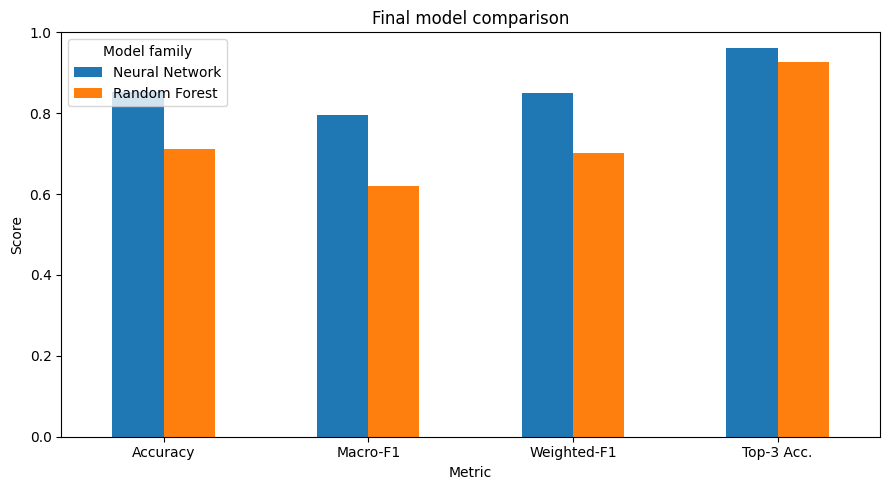

In [30]:
# Final model comparison
metrics_to_plot = ["Accuracy", "Macro-F1", "Weighted-F1", "Top-3 Acc."]

plot_df = final_comparison.set_index("Family")[metrics_to_plot]

ax = plot_df.T.plot(kind="bar", figsize=(9, 5))
ax.set_title("Final model comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Model family")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "final_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

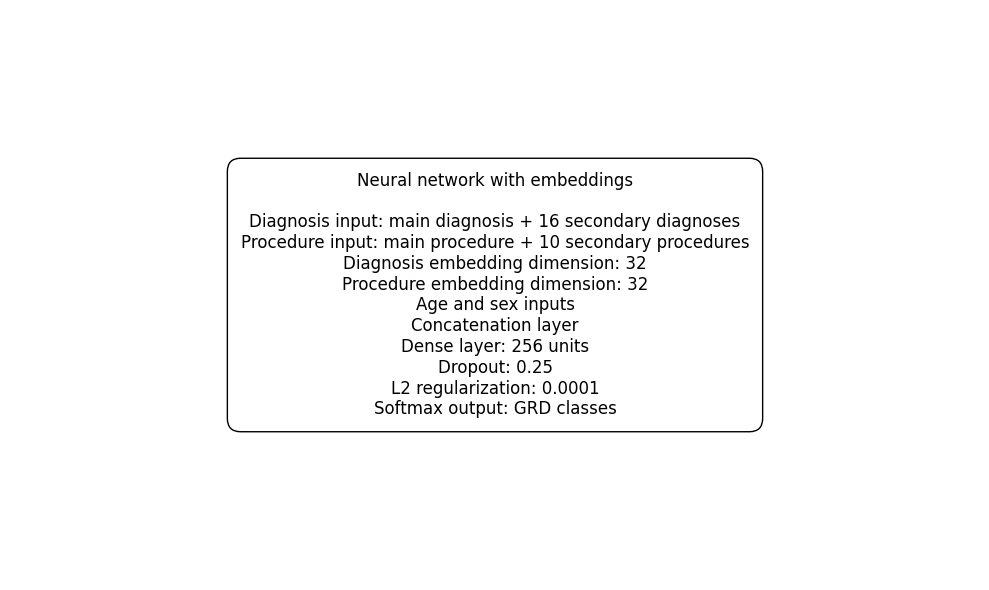

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

architecture_text = (
    "Neural network with embeddings\n\n"
    "Diagnosis input: main diagnosis + 16 secondary diagnoses\n"
    "Procedure input: main procedure + 10 secondary procedures\n"
    "Diagnosis embedding dimension: 32\n"
    "Procedure embedding dimension: 32\n"
    "Age and sex inputs\n"
    "Concatenation layer\n"
    "Dense layer: 256 units\n"
    "Dropout: 0.25\n"
    "L2 regularization: 0.0001\n"
    "Softmax output: GRD classes"
)

ax.text(
    0.5,
    0.5,
    architecture_text,
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round", pad=0.8, fill=False)
)

plt.tight_layout()
plt.savefig(FIG_DIR / "nn_architecture.png", dpi=200, bbox_inches="tight")
plt.show()